In [18]:
# --- TOP CELL: RUN THIS ONCE ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import numpy as np # Ensure numpy is imported too
from scipy.integrate import solve_ivp
from scipy.optimize import differential_evolution
import os
# -------------------------------

In [3]:
import pandas as pd
import numpy as np
import os

print("Cell 1: Memuat dataset hasil pemrosesan...")

MW = {
    'desb30': 5706.524, 'detemir': 5916.885, 'A1': 5916.885, 
    'A1_B1': 6127.246, 'A1_B29': 6127.246, 'B1_B29': 6127.246, 
    'A1_B29_B1': 6337.607, 'B1': 5916.885, 'nhs_myr': 325.449, 'nhs': 115.088
}

# Pastikan daftar ini sesuai dengan nilai unik di kolom 'Peak Identification' file kita
species_list = ['desb30', 'A1', 'detemir', 'A1_B29', 'B1_B29', 'A1_B29_B1', 'A1_B1', 'B1']

csv_filename = 'kinetic_data_processed.csv'
if not os.path.exists(csv_filename):
    raise FileNotFoundError(f"File '{csv_filename}' tidak ditemukan!")

df = pd.read_csv(csv_filename)

# Pastikan tipe data benar
df['Time'] = df['Time'].astype(float)
df['Perbandingan'] = df['Perbandingan'].astype(float)

experimental_dataset = {}
ratios = sorted(df['Perbandingan'].unique())
# Dapatkan daftar waktu unik yang tersedia dalam data (diurutkan)
time_points = sorted(df['Time'].unique())

for r in ratios:
    df_ratio = df[df['Perbandingan'] == r]
    experimental_dataset[r] = {}
    
    for sp in species_list:
        # Ambil data untuk spesies ini, urutkan berdasarkan Time
        sub_df = df_ratio[df_ratio['Peak Identification'] == sp].sort_values('Time')
        
        # Ekstrak konsentrasi (g/L) dan bagi dengan MW untuk mendapatkan Molaritas
        # Kita gunakan reindex untuk memastikan semua time_points ada (mengisi NaN dengan 0.0)
        conc_series = sub_df.set_index('Time').reindex(time_points, fill_value=0.0)['Conc']
        
        experimental_dataset[r][sp] = np.array(conc_series) / MW.get(sp, 1.0)

print("Cell 1 Selesai: Dataset telah dikonversi ke Molaritas.")
# Opsional: Cek hasil untuk satu perbandingan
print(f"Time points: {time_points}")
print(f"Contoh data (Ratio 1.0, desb30): {experimental_dataset[1.0]['desb30'][:5]}")

Cell 1: Memuat dataset hasil pemrosesan...
Cell 1 Selesai: Dataset telah dikonversi ke Molaritas.
Time points: [np.float64(0.0), np.float64(2.0), np.float64(4.0), np.float64(6.0), np.float64(8.0), np.float64(10.0), np.float64(13.0), np.float64(16.0), np.float64(19.0), np.float64(22.0), np.float64(25.0), np.float64(30.0), np.float64(35.0), np.float64(40.0), np.float64(45.0), np.float64(50.0), np.float64(60.0), np.float64(70.0), np.float64(80.0), np.float64(100.0), np.float64(120.0)]
Contoh data (Ratio 1.0, desb30): [2.53253995e-04 7.90481211e-05 4.58773152e-05 3.68893568e-05
 3.47426910e-05]


In [23]:
class FinalKineticModel:
    def __init__(self, params):
        self.k = params[:7]
        self.n = params[7]
        self.m = params[8]
        
        self.species = ['nhs_myr', 'desb30', 'A1', 'detemir', 'B1', 'A1_B29', 'B1_B29', 'A1_B1', 'A1_B29_B1']
        self.idx = {name: i for i, name in enumerate(self.species)}

    def _ode_system(self, t, y):
        y_clip = np.maximum(y, 0)
        idx = self.idx
        
        C_nhsm = y_clip[idx['nhs_myr']]
        C_desb = y_clip[idx['desb30']]
        C_a1   = y_clip[idx['A1']]
        C_det  = y_clip[idx['detemir']]
        C_a1b29= y_clip[idx['A1_B29']]
        
        # Reaction Rates
        r1 = self.k[0] * (C_nhsm**self.n) * (C_desb**self.m)
        r2 = self.k[1] * (C_nhsm**self.n) * (C_desb**self.m)
        r3 = self.k[2] * (C_nhsm**self.n) * (C_desb**self.m)
        
        r4 = self.k[3] * (C_nhsm**self.n) * (C_a1**self.m)
        r5 = self.k[4] * (C_nhsm**self.n) * (C_a1**self.m)
        
        r6 = self.k[5] * (C_nhsm**self.n) * (C_det**self.m)
        r7 = self.k[6] * (C_nhsm**self.n) * (C_a1b29**self.m)
        
        dydt = np.zeros_like(y)
        
        dydt[idx['nhs_myr']]  = -(r1 + r2 + r3 + r4 + r5 + r6 + r7)
        dydt[idx['desb30']]   = -(r1 + r2 + r3)
        dydt[idx['A1']]       = r1 - (r4 + r5)
        dydt[idx['B1']]       = r2
        dydt[idx['detemir']]  = r3 - r6
        dydt[idx['A1_B1']]    = r4
        dydt[idx['A1_B29']]   = r5 - r7
        dydt[idx['B1_B29']]   = r6
        dydt[idx['A1_B29_B1']]= r7
        
        return dydt

    def simulate(self, y0, t_span, t_eval):
        return solve_ivp(self._ode_system, t_span, y0, t_eval=np.sort(t_eval), 
                         method='Radau', atol=1e-8, rtol=1e-6)

# Ensure time_exp is defined in the current cell
time_exp = np.sort(df['Time'].unique())

In [10]:
def get_initial_conditions(ratio, experimental_dataset):
    # 1. Get desb30 molarity at t=0
    desb30_t0 = experimental_dataset[ratio]['desb30'][0]
    
    # 2. Calculate nhs_myr as requested
    nhs_myr_t0 = desb30_t0 * ratio
    
    # 3. Build the y0 array based on the class order
    # Note: Products are 0.0 at t=0
    y0 = np.zeros(9)
    y0[idx['nhs_myr']] = nhs_myr_t0
    y0[idx['desb30']]  = desb30_t0
    # Everything else (A1, detemir, etc.) stays 0.0
    
    return y0

In [24]:
# --- 1. DEFINE WEIGHTS (Outside the function, for easy adjustment) ---
weights = {
    'desb30': 2.0, 'A1': 1.0, 'detemir': 1.5, 
    'B1': 0.5, 'A1_B1': 0.5, 'A1_B29': 0.5, 'B1_B29': 0.5, 'A1_B29_B1': 0.5
}

# --- 2. UPDATED OBJECTIVE FUNCTION (With Weighted SSE) ---
def objective_function_global(log_params):
    k_vals = np.exp(log_params[:7])
    n, m = log_params[7], log_params[8]
    full_params = list(k_vals) + [n, m]
    
    total_sse_weighted = 0
    ratios = [1.0, 1.5, 2.0]
    model = FinalKineticModel(full_params)
    epsilon = 1e-6
    
    for r in ratios:
        desb30_t0_molL = experimental_dataset[r]['desb30'][0]
        y0 = np.zeros(len(model.species))
        y0[model.idx['nhs_myr']] = desb30_t0_molL * r
        y0[model.idx['desb30']] = desb30_t0_molL
            
        sol = model.simulate(y0, (0, 120), time_exp)
        if not sol.success: return 1e10
        
        for sp in model.species:
            if sp == 'nhs_myr': continue
            
            sim_vals = sol.y[model.idx[sp]] * MW[sp]
            exp_vals = experimental_dataset[r][sp] * MW[sp]
            
            mask = ~np.isnan(exp_vals) & (exp_vals > epsilon)
            if np.any(mask):
                # Apply Weighting here
                rel_error = (sim_vals[mask] - exp_vals[mask]) / exp_vals[mask]
                total_sse_weighted += np.sum((rel_error * weights[sp])**2)
            
    return total_sse_weighted

# --- 3. TWO-STAGE REFINEMENT (The Execution Block) ---
from scipy.optimize import minimize

print("Stage 1: Global optimization (Differential Evolution)...")
res_de = differential_evolution(objective_function_global, bounds, popsize=20, maxiter=50, seed=42)

print("Stage 2: Local refinement (L-BFGS-B Polishing)...")
res_final = minimize(objective_function_global, res_de.x, method='L-BFGS-B', bounds=bounds)

# Now use res_final.x as your 'final_params'
final_params = res_final.x
print(f"Refined SSE: {res_final.fun:.4f}")

Stage 1: Global optimization (Differential Evolution)...
Stage 2: Local refinement (L-BFGS-B Polishing)...
Refined SSE: 161.1791


In [25]:
opt_k = np.exp(result.x[:7])
opt_orders = result.x[7:]
final_params = list(opt_k) + list(opt_orders)

print("\n================== HASIL KINETIKA MEKANISTIK GLOBAL ==================")
pathway_names = [
    'k1 (DesB30 -> A1)      ', 'k2 (DesB30 -> B1)      ', 'k3 (DesB30 -> Detemir) ',
    'k4 (A1 -> A1_B1)       ', 'k5 (A1 -> A1_B29)      ', 'k6 (Detemir -> B1_B29) ',
    'k7 (A1_B29 -> Tri)     '
]
for name, val in zip(pathway_names, opt_k):
    print(f"  {name}: {val:.4e}")
print(f"  Order 'n' (NHS-myr)         : {opt_orders[0]:.3f}")
print(f"  Order 'm' (Substrat Insulin): {opt_orders[1]:.3f}")
print(f"  Final Minimum SSE (g/L)     : {result.fun:.5f}")
print("======================================================================\n")

# 1. Define the model with the final optimized parameters
model = FinalKineticModel(final_params)

print("=== ANALISIS MASS CONVERSION & YIELD (MENIT KE-120) ===")
for r in ratios:
    # Use the same logic we used in the objective function
    desb30_t0_molL = experimental_dataset[r]['desb30'][0]
    
    y0 = np.zeros(len(model.species))
    y0[model.idx['nhs_myr']] = desb30_t0_molL * r
    y0[model.idx['desb30']] = desb30_t0_molL
    # Other products are 0.0 by default
        
    model = FinalKineticModel(final_params)
    sol = model.simulate(y0, (0, 120), time_exp)
    
    # Use model.idx to safely grab the final concentrations
    desb30_0_mass = desb30_t0_molL * MW['desb30']
    desb30_akhir_mass = sol.y[model.idx['desb30']][-1] * MW['desb30']
    detemir_akhir_mass = sol.y[model.idx['detemir']][-1] * MW['detemir']
    
    konversi = ((desb30_0_mass - desb30_akhir_mass) / desb30_0_mass) * 100
    yield_detemir = (detemir_akhir_mass / desb30_0_mass) * 100
    
    print(f"Rasio Skenario : {r}")
    print(f"  -> Konversi Massa DesB30 : {konversi:.2f}%")
    print(f"  -> Yield Hasil Detemir    : {yield_detemir:.2f}%")


================== HASIL KINETIKA MEKANISTIK GLOBAL ==================
  k1 (DesB30 -> A1)      : 5.2397e+02
  k2 (DesB30 -> B1)      : 3.7809e-04
  k3 (DesB30 -> Detemir) : 4.3373e+03
  k4 (A1 -> A1_B1)       : 3.7297e-04
  k5 (A1 -> A1_B29)      : 1.0000e+04
  k6 (Detemir -> B1_B29) : 3.4316e+00
  k7 (A1_B29 -> Tri)     : 2.1186e+01
  Order 'n' (NHS-myr)         : 1.059
  Order 'm' (Substrat Insulin): 1.021
  Final Minimum SSE (g/L)     : 164.10176

=== ANALISIS MASS CONVERSION & YIELD (MENIT KE-120) ===
Rasio Skenario : 1.0
  -> Konversi Massa DesB30 : 90.94%
  -> Yield Hasil Detemir    : 84.03%
Rasio Skenario : 1.5
  -> Konversi Massa DesB30 : 100.00%
  -> Yield Hasil Detemir    : 91.81%
Rasio Skenario : 2.0
  -> Konversi Massa DesB30 : 100.00%
  -> Yield Hasil Detemir    : 91.19%


=== ANALISIS ERROR PER SKENARIO RASIO ===
Rasio 1 : 1.0 -> RMSE = 0.1836 g/L
Rasio 1 : 1.5 -> RMSE = 0.0739 g/L
Rasio 1 : 2.0 -> RMSE = 0.0478 g/L


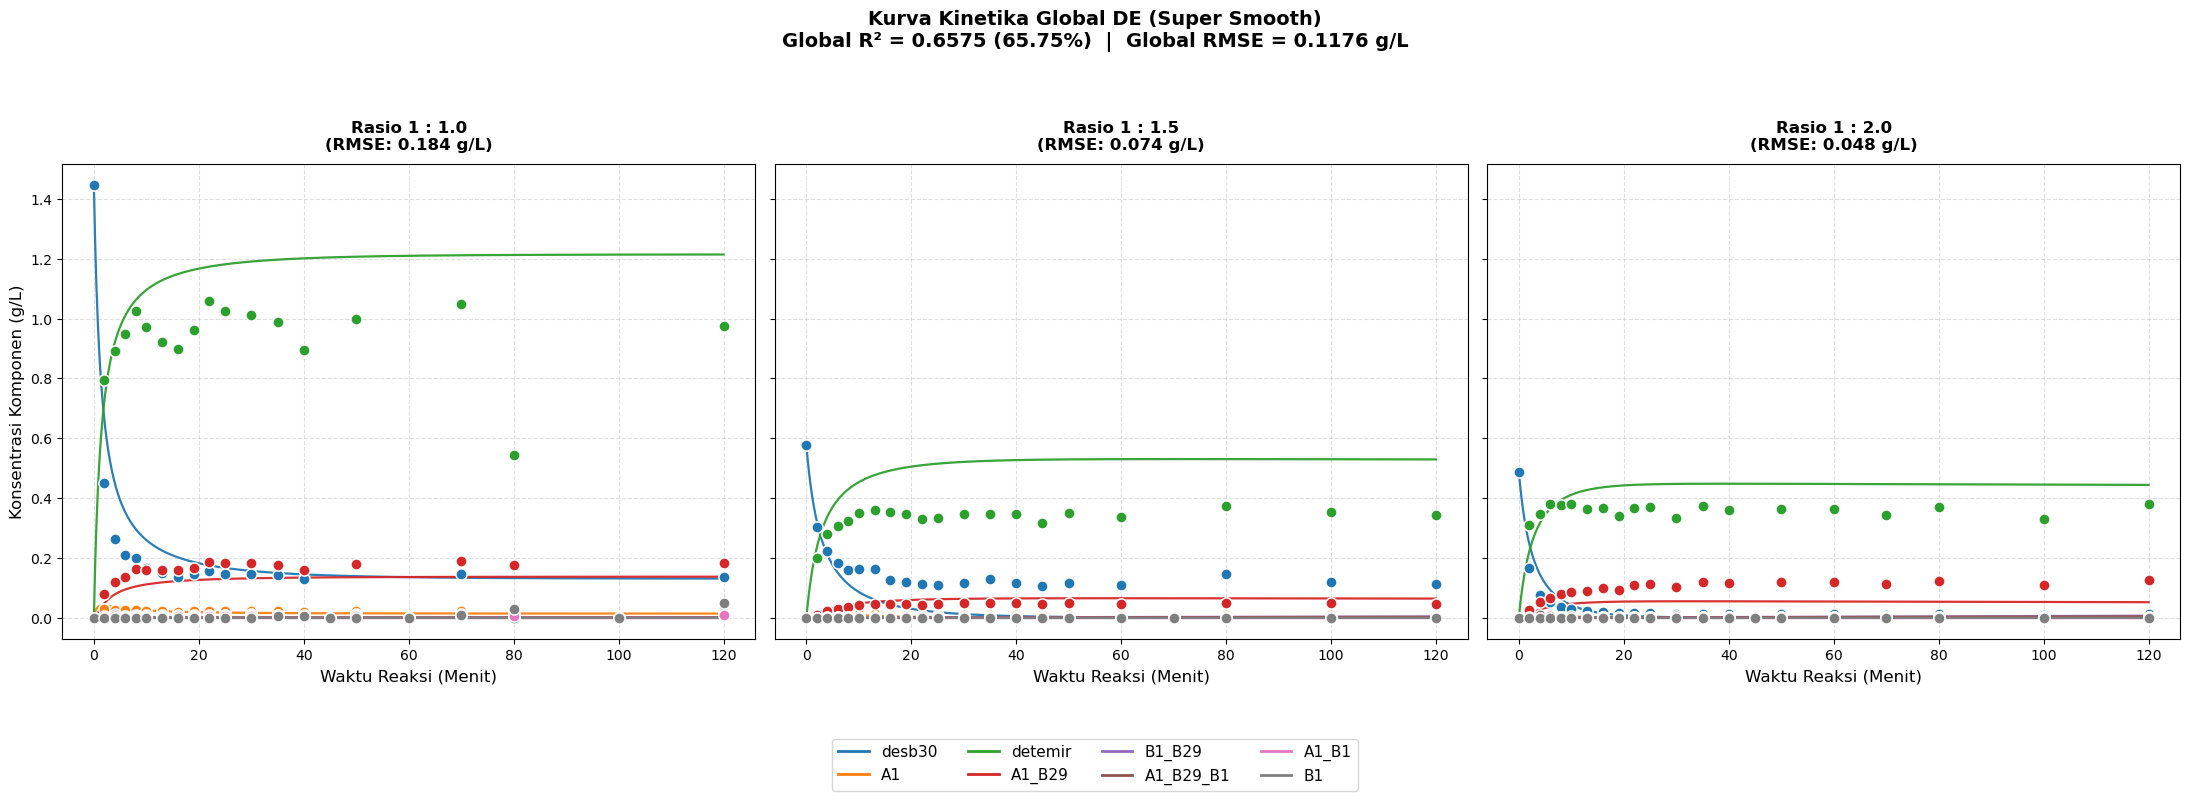


==================== RINGKASAN PERFORMA MODEL ====================
 >> Akurasi Tren (Global R²) : 0.6575 (65.75%)
 >> Deviasi Rata-rata (Global RMSE) : 0.1176 g/L


In [27]:
from sklearn.metrics import mean_squared_error, r2_score # Added r2_score

y_true_global, y_pred_global = [], []

plot_colors = {
    'desb30': '#1f77b4', 'A1': '#ff7f0e', 'detemir': '#2ca02c', 
    'A1_B29': '#d62728', 'B1_B29': '#9467bd', 'A1_B29_B1': '#8c564b', 
    'A1_B1': '#e377c2', 'B1': '#7f7f7f'
}

time_smooth = np.linspace(0, 120, 1000)
fig, axes = plt.subplots(1, 3, figsize=(22, 6.5), sharey=True)

print("=== ANALISIS ERROR PER SKENARIO RASIO ===")

# Ensure final_params exists (it was defined in your previous step)
# Then instantiate a fresh model object
model = FinalKineticModel(final_params)

for idx, r in enumerate(ratios):
    # DYNAMIC Y0: Matches your objective function logic
    desb30_t0_molL = experimental_dataset[r]['desb30'][0]
    y0 = np.zeros(len(model.species))
    y0[model.idx['nhs_myr']] = desb30_t0_molL * r
    y0[model.idx['desb30']] = desb30_t0_molL
        
    model = FinalKineticModel(final_params)
    sol_smooth = model.simulate(y0, (0, 120), time_smooth)
    sol_exp = model.simulate(y0, (0, 120), time_exp)
    
    # Use a list to store data for this ratio for local RMSE
    r_true, r_pred = [], []
    
    for sp in species_list:
        # DYNAMIC INDEXING: safer and cleaner
        ode_pos = model.idx[sp]
        
        sim_gL_smooth = sol_smooth.y[ode_pos] * MW[sp]
        sim_gL_exp = sol_exp.y[ode_pos] * MW[sp]
        exp_gL = experimental_dataset[r][sp] * MW[sp]
        
        # Masking NaNs to prevent calculation failure
        mask = ~np.isnan(exp_gL)
        r_true.extend(exp_gL[mask])
        r_pred.extend(sim_gL_exp[mask])
        
        # Add to global trackers
        y_true_global.extend(exp_gL[mask])
        y_pred_global.extend(sim_gL_exp[mask])
        
        axes[idx].plot(time_smooth, sim_gL_smooth, color=plot_colors[sp], linewidth=1.6, alpha=0.95)
        axes[idx].scatter(time_exp, exp_gL, color=plot_colors[sp], edgecolors='white', linewidth=1.1, s=65, zorder=5)

    rmse_ratio = np.sqrt(mean_squared_error(r_true, r_pred))
    print(f"Rasio 1 : {r:.1f} -> RMSE = {rmse_ratio:.4f} g/L")
    
    ax = axes[idx]
    ax.set_title(f"Rasio 1 : {r:.1f}\n(RMSE: {rmse_ratio:.3f} g/L)", fontsize=12, fontweight='bold', pad=10)
    ax.set_xlabel("Waktu Reaksi (Menit)", fontsize=12)
    if idx == 0:
        ax.set_ylabel("Konsentrasi Komponen (g/L)", fontsize=12)
    ax.grid(True, linestyle='--', alpha=0.4)

# Hitung Statistik Global Akhir
global_r2 = r2_score(y_true_global, y_pred_global)
global_rmse = np.sqrt(mean_squared_error(y_true_global, y_pred_global))

# Penataan Legend & Title
handles, labels = axes[0].get_legend_handles_labels()
# Mengambil label unik tiruan untuk memunculkan legenda kromatogram tanpa tulisan "(Model)" berulang
dummy_handles = [plt.Line2D([0], [0], color=plot_colors[sp], lw=2) for sp in species_list]
fig.legend(dummy_handles, species_list, loc='upper center', bbox_to_anchor=(0.5, -0.05), ncol=4, fontsize=11, frameon=True)

plt.suptitle(f"Kurva Kinetika Global DE (Super Smooth)\nGlobal R² = {global_r2:.4f} ({global_r2*100:.2f}%)  |  Global RMSE = {global_rmse:.4f} g/L", 
             fontsize=14, fontweight='bold', y=1.06)

plt.tight_layout()
plt.show()

print("\n==================== RINGKASAN PERFORMA MODEL ====================")
print(f" >> Akurasi Tren (Global R²) : {global_r2:.4f} ({global_r2*100:.2f}%)")
print(f" >> Deviasi Rata-rata (Global RMSE) : {global_rmse:.4f} g/L")
print("==================================================================")

In [28]:
my_final_model = ExpandedKineticModel(final_params_full)
model_file_path = 'multi_ratio_kinetic_optimized_model.dill'

with open(model_file_path, 'wb') as f:
    dill.dump(my_final_model, f)
print(f"\nKinetic MODEL Multi-Rasio sukses disimpan ke '{model_file_path}'!")

NameError: name 'ExpandedKineticModel' is not defined

In [29]:
# Check total mass at t=0 and t=120
total_mass_t0 = np.sum([y0[model.idx[sp]] * MW[sp] for sp in model.species])
total_mass_t120 = np.sum([sol.y[model.idx[sp]][-1] * MW[sp] for sp in model.species])
print(f"Mass Balance Error: {abs(total_mass_t0 - total_mass_t120)/total_mass_t0 * 100:.2f}%")

Mass Balance Error: 2.04%
